In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# ==========================================================
# 1. DATA PREPARATION & SLICING
# ==========================================================
# Load dataset
# NOTE: header uses ", " so column names carry leading spaces -> strip them
df = pd.read_csv('structural_full_68_68_16_edited.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()

# --- Feature Extraction ---
# Whole-brain morphometry: 8th column (index 7) to end
X_morph = df.iloc[:, 7:].values
morph_features = df.columns[7:].tolist()

# Biological & Technical Confounders (to regress out)
X_nuisance = df[['age', 'sex', 'eTIV']].values

# Clinical / Experimental Predictors (kept intact)
X_clinical = df[['vas_t0', 'treatment_group']].values

# Target Variable
y = df['vas_t1'].values


In [3]:

# ==========================================================
# 2. CROSS-VALIDATION PIPELINE (ELASTICNET + RESIDUALIZATION)
# ==========================================================
loo = LeaveOneOut()

y_true = []
y_pred = []
feature_weights = []
best_params_log = []

print(f"Starting LOOCV with ElasticNet across {len(morph_features)} whole-brain features...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_morph)):
    # --- A. Split into Train / Test Folds ---
    X_m_train, X_m_test = X_morph[train_idx], X_morph[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- B. Nuisance Covariate Residualization ---
    # Fit linear regressor strictly on training fold
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_m_train)

    # Calculate residuals: Morphometry_clean = Morphometry_raw - Confounders_effect
    X_m_train_clean = X_m_train - nuisance_regressor.predict(X_n_train)
    X_m_test_clean = X_m_test - nuisance_regressor.predict(X_n_test)

    # --- C. Assemble Final Feature Set ---
    X_train_final = np.hstack([X_m_train_clean, X_c_train])
    X_test_final = np.hstack([X_m_test_clean, X_c_test])

    # --- D. Feature Scaling ---
    # Penalised models are scale-sensitive; Z-scoring is essential
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_final)
    X_test_scaled = scaler.transform(X_test_final)

    # --- E. ElasticNet Hyperparameter Tuning via Inner CV ---
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0],      # Overall regularisation strength
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]      # L1 (Lasso) vs L2 (Ridge) balance
    }

    base_model = ElasticNet(max_iter=10000, random_state=42)
    inner_cv = GridSearchCV(
        base_model,
        param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=1
    )
    inner_cv.fit(X_train_scaled, y_train)

    # --- F. Predict with Best Model (GridSearchCV already refits on full train fold) ---
    best_model = inner_cv.best_estimator_

    pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(pred[0])
    feature_weights.append(best_model.coef_)   # ElasticNet coefficients (1-D)
    best_params_log.append(inner_cv.best_params_)


Starting LOOCV with ElasticNet across 152 whole-brain features...



In [4]:
feature_weights

[array([-0.        ,  0.        , -0.        , -0.        ,  0.        ,
        -0.        , -0.        , -0.        ,  0.        , -0.        ,
        -0.        , -0.        , -0.        , -0.        ,  0.        ,
        -0.        ,  0.        , -0.        , -0.        ,  0.        ,
         0.        , -0.        , -0.        , -0.        ,  0.        ,
        -0.        , -0.        , -0.        , -0.        ,  0.        ,
        -0.        , -0.        ,  0.        , -0.        , -0.        ,
         0.        , -0.        , -0.        , -0.        , -0.        ,
        -0.        , -0.        ,  0.        , -0.        , -0.        ,
        -0.        , -0.        , -0.        ,  0.        , -0.        ,
        -0.        , -0.        , -0.        , -0.        ,  0.        ,
         0.        , -0.        , -0.        , -0.        , -0.        ,
        -0.        , -0.        , -0.        , -0.        , -0.        ,
         0.        , -0.        , -0.        ,  0. 

In [5]:

# ==========================================================
# 3. EVALUATION & SUBGROUP PERFORMANCE
# ==========================================================
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Overall Metrics ---
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]

print("============ OVERALL ELASTICNET EVALUATION ============")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R-squared (R^2) Score      : {r2:.4f}")
print(f"Pearson Correlation (r)    : {corr:.4f}")
print("========================================================")

# --- Subgroup Evaluation: Active (2) vs. Sham (1) ---
treatment_vec = df['treatment_group'].values
active_mask = (treatment_vec == 2)
sham_mask = (treatment_vec == 1)

# Active Group
y_true_act, y_pred_act = y_true[active_mask], y_pred[active_mask]
r2_act, corr_act = r2_score(y_true_act, y_pred_act), np.corrcoef(y_true_act, y_pred_act)[0, 1]
rmse_act = np.sqrt(mean_squared_error(y_true_act, y_pred_act))

# Sham Group
y_true_shm, y_pred_shm = y_true[sham_mask], y_pred[sham_mask]
r2_shm, corr_shm = r2_score(y_true_shm, y_pred_shm), np.corrcoef(y_true_shm, y_pred_shm)[0, 1]
rmse_shm = np.sqrt(mean_squared_error(y_true_shm, y_pred_shm))

print("\n================ SUBGROUP PERFORMANCE ================")
print(f"ACTIVE GROUP [2] (N = {np.sum(active_mask)}): R^2 = {r2_act:.4f} | r = {corr_act:.4f} | RMSE = {rmse_act:.4f}")
print(f"SHAM GROUP   [1] (N = {np.sum(sham_mask)}): R^2 = {r2_shm:.4f} | r = {corr_shm:.4f} | RMSE = {rmse_shm:.4f}")
print("======================================================")

# --- Feature Importance Report ---
all_features = morph_features + ['craving_T0', 'treatment_group']
avg_weights = np.mean(feature_weights, axis=0)

weights_df = pd.DataFrame({
    'Feature': all_features,
    'Avg_ENet_Weight': avg_weights,
    'Abs_Weight': np.abs(avg_weights)
}).sort_values(by='Abs_Weight', ascending=False)

print("\n--- Top 15 Predictive Features (ElasticNet Weights) ---")
print(weights_df[['Feature', 'Avg_ENet_Weight']].head(15).to_string(index=False))


============ OVERALL ELASTICNET EVALUATION ============
Mean Squared Error (MSE)   : 5.9524
Root Mean Squared Error    : 2.4398
R-squared (R^2) Score      : -0.0491
Pearson Correlation (r)    : -0.2117

================ SUBGROUP PERFORMANCE ================
ACTIVE GROUP [2] (N = 25): R^2 = -0.0932 | r = -0.2341 | RMSE = 2.4131
SHAM GROUP   [1] (N = 20): R^2 = -0.0618 | r = -0.0940 | RMSE = 2.4727

--- Top 15 Predictive Features (ElasticNet Weights) ---
                        Feature  Avg_ENet_Weight
                     craving_T0         0.211377
lh_caudalanteriorcingulate_area         0.006249
              lh_bankssts_thick         0.000000
             rh_entorhinal_area         0.000000
           lh_temporalpole_area         0.000000
     lh_transversetemporal_area         0.000000
                 lh_insula_area         0.000000
               rh_bankssts_area         0.000000
rh_caudalanteriorcingulate_area         0.000000
    rh_caudalmiddlefrontal_area         0.000000
    

In [6]:

# ==========================================================
# 3b. DIAGNOSTICS  (why the model behaves the way it does)
# ==========================================================
from collections import Counter

# Did the inner CV push regularisation to its maximum?
print("Selected alpha    :", Counter([p['alpha'] for p in best_params_log]).most_common())
print("Selected l1_ratio :", Counter([p['l1_ratio'] for p in best_params_log]).most_common())

# How many of the 154 coefficients survive the L1 penalty, on average?
nonzero = [int(np.sum(w != 0)) for w in feature_weights]
print(f"\nNon-zero coefficients per fold : mean {np.mean(nonzero):.1f} / {len(all_features)}"
      f"  (min {min(nonzero)}, max {max(nonzero)})")

# Does the model actually move, or does it predict a near-constant?
print(f"\nSD of predictions : {y_pred.std():.3f}")
print(f"SD of true y      : {y_true.std():.3f}")
print(f"Ratio             : {y_pred.std() / y_true.std():.3f}   (1.0 = full dynamic range, 0 = flat)")

# Reference: same pipeline using ONLY the clinical predictors
y_pred_clin = []
for train_idx, test_idx in loo.split(X_clinical):
    sc = StandardScaler().fit(X_clinical[train_idx])
    gs = GridSearchCV(ElasticNet(max_iter=10000, random_state=42),
                      param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
    gs.fit(sc.transform(X_clinical[train_idx]), y[train_idx])
    y_pred_clin.append(gs.best_estimator_.predict(sc.transform(X_clinical[test_idx]))[0])
y_pred_clin = np.array(y_pred_clin)

print("\n---------------- BASELINE COMPARISON ----------------")
print(f"Whole-brain (152) + clinical : R^2 = {r2:.4f} | r = {corr:+.4f}")
print(f"Clinical only  (2 features)  : R^2 = {r2_score(y_true, y_pred_clin):.4f} "
      f"| r = {np.corrcoef(y_true, y_pred_clin)[0, 1]:+.4f}")
print("-----------------------------------------------------")


Selected alpha    : [(1.0, 44), (5.0, 1)]
Selected l1_ratio : [(0.9, 43), (0.3, 1), (0.7, 1)]

Non-zero coefficients per fold : mean 1.0 / 154  (min 0, max 2)

SD of predictions : 0.225
SD of true y      : 2.382
Ratio             : 0.095   (1.0 = full dynamic range, 0 = flat)

---------------- BASELINE COMPARISON ----------------
Whole-brain (152) + clinical : R^2 = -0.0491 | r = -0.2117
Clinical only  (2 features)  : R^2 = 0.1607 | r = +0.4179
-----------------------------------------------------


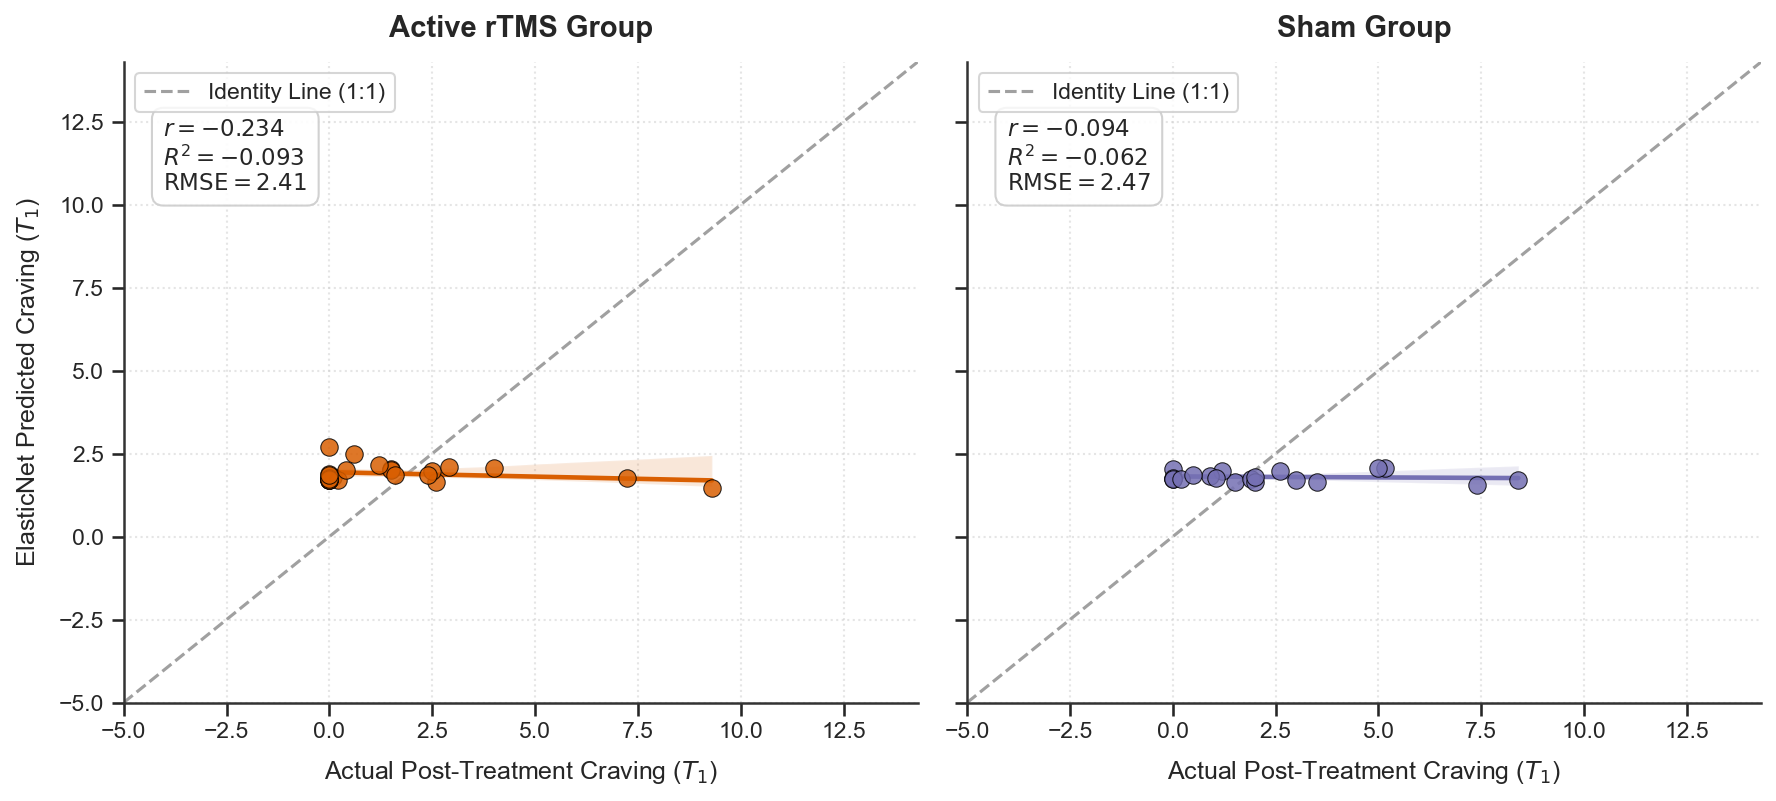

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set clean publication aesthetic
sns.set_theme(style="ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

# 1. Map group codes (2 -> Active rTMS, 1 -> Sham)
plot_df = pd.DataFrame({
    'True_Craving': y_true,
    'Pred_Craving': y_pred,
    'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
})

# 2. Setup figure canvas
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=150)

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'} # High-contrast colorblind-safe palette

groups = ['Active rTMS', 'Sham']
metrics = [
    {'r': corr_act, 'r2': r2_act, 'rmse': rmse_act},
    {'r': corr_shm, 'r2': r2_shm, 'rmse': rmse_shm}
]

# 3. Plot Active vs. Sham side-by-side
for i, grp in enumerate(groups):
    ax = axes[i]
    sub_df = plot_df[plot_df['Group'] == grp]
    m = metrics[i]
    color = palette[grp]

    # Draw 1:1 Identity Line (Perfect Prediction)
    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 5
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 5
    ax.plot([min_val, max_val], [min_val, max_val], color='#A0A0A0', linestyle='--', linewidth=1.5, label='Identity Line (1:1)', zorder=1)

    # Scatter points for actual vs. predicted values
    sns.scatterplot(
        data=sub_df, x='True_Craving', y='Pred_Craving',
        color=color, s=70, alpha=0.85, edgecolor='black', linewidth=0.5, ax=ax, zorder=3
    )

    # Linear Regression Fit with 95% Confidence Interval
    sns.regplot(
        data=sub_df, x='True_Craving', y='Pred_Craving',
        ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
    )

    # Formatting & Subgroup Titles
    ax.set_title(f'{grp} Group', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
    if i == 0:
        ax.set_ylabel('ElasticNet Predicted Craving ($T_1$)', fontsize=12, labelpad=8)

    # Annotate statistical metrics inside each plot
    stats_text = f"$r = {m['r']:.3f}$\n$R^2 = {m['r2']:.3f}$\n$\\mathrm{{RMSE}} = {m['rmse']:.2f}$"
    ax.text(
        0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC')
    )

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()

# Save high-res figure
plt.savefig('SUDMEX_ENet_WholeBrain_Active_vs_Sham.png', dpi=300, bbox_inches='tight')
plt.show()


vas_t1은 vas_t0로 예측되고 (r=0.475, p<0.0001), 구조 MRI는 아무것도 더하지 않는다. 이건 실패가 아니라 정당한 null finding이고, 지금 permutation까지 붙어 있어서 논문에 그대로 쓸 수 있는 형태입니다